# SalesPilot — Full Demo
### CRM Account Scoring + Optimized Visit Route Planning

**Author:** Kanaka Sarat Siripurapu &nbsp;|&nbsp; **SJSU ID:** 019132776

**Tech Stack:**
- **Backend:** FastAPI + PostgreSQL + SQLAlchemy
- **ML:** XGBoost binary classifier (scikit-learn pipeline)
- **Optimization:** Google OR-Tools TSP solver (Haversine distances)
- **Visualization:** Folium interactive maps + Matplotlib/Seaborn

---

**What SalesPilot does:**
1. Loads CRM sales pipeline data (accounts, products, sales teams, opportunities)
2. Trains an ML model to predict which deals will close (win probability)
3. Scores accounts by priority so a sales rep knows who to visit
4. Computes an optimal round-trip route using TSP optimization
5. Exposes everything via a REST API

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Ensure we're in the salespilot project root
os.chdir('/Users/kanakasarat/Downloads/CRM+Sales+Opportunities/salespilot')
sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, subprocess, joblib, httpx
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

CSV_DIR = Path('..')
print('SalesPilot Demo ready.')

SalesPilot Demo ready.


---
## 1. Data Overview
Load and explore the CRM Sales Opportunities dataset (85 accounts, 8,800 pipeline deals).

In [2]:
# Load raw CSVs
accounts_raw = pd.read_csv(CSV_DIR / 'accounts.csv')
pipeline_raw = pd.read_csv(CSV_DIR / 'sales_pipeline.csv')
products_raw = pd.read_csv(CSV_DIR / 'products.csv')
teams_raw    = pd.read_csv(CSV_DIR / 'sales_teams.csv')

print(f'Accounts:       {accounts_raw.shape[0]:,} rows x {accounts_raw.shape[1]} cols')
print(f'Pipeline deals: {pipeline_raw.shape[0]:,} rows x {pipeline_raw.shape[1]} cols')
print(f'Products:       {products_raw.shape[0]:,} rows')
print(f'Sales Teams:    {teams_raw.shape[0]:,} agents')
print()
accounts_raw.head()

Accounts:       85 rows x 7 cols
Pipeline deals: 8,800 rows x 8 cols
Products:       7 rows
Sales Teams:    35 agents



,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN


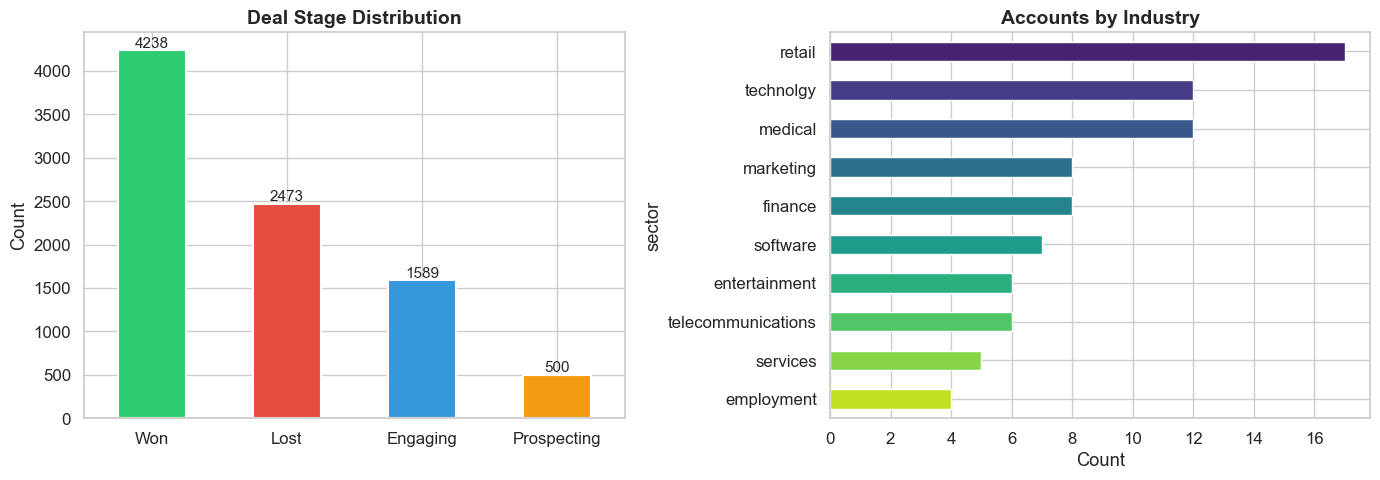

Win rate: 48.2%


In [3]:
# --- Chart 1: Deal Stage Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: deal stages
stage_counts = pipeline_raw['deal_stage'].value_counts()
colors_stage = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
stage_counts.plot.bar(ax=axes[0], color=colors_stage, edgecolor='white', linewidth=1.5)
axes[0].set_title('Deal Stage Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].bar_label(axes[0].containers[0], fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

# Right: industry breakdown
industry_counts = accounts_raw['sector'].value_counts()
industry_counts.plot.barh(ax=axes[1], color=sns.color_palette('viridis', len(industry_counts)), edgecolor='white')
axes[1].set_title('Accounts by Industry', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('demo_charts_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Win rate:', f'{(pipeline_raw["deal_stage"]=="Won").mean():.1%}')

---
## 2. Data Pipeline: CSV to PostgreSQL
The `data_loader` module transforms raw CSVs, generates synthetic geo-coordinates, resolves foreign keys, and bulk-upserts into PostgreSQL.

In [4]:
from app.data.data_loader import _load_accounts, _load_products, _load_sales_teams, _load_opportunities

acct_df = _load_accounts(CSV_DIR)
prod_df = _load_products(CSV_DIR)
team_df = _load_sales_teams(CSV_DIR)

# Build FK lookups
account_lookup = dict(zip(acct_df['account_name'].str.strip().str.lower(), acct_df['account_id']))
agent_lookup   = dict(zip(team_df['sales_agent'].str.strip().str.lower(), team_df['agent_id']))
product_lookup = dict(zip(prod_df['product_name'].str.strip().str.lower(), prod_df['product_id']))

opp_df = _load_opportunities(CSV_DIR, account_lookup, agent_lookup, product_lookup)

print(f'Accounts:      {len(acct_df):>6,}  (with synthetic lat/lon)')
print(f'Products:      {len(prod_df):>6,}')
print(f'Sales Agents:  {len(team_df):>6,}')
print(f'Opportunities: {len(opp_df):>6,}')
print()
print('Sample accounts with geo-coordinates:')
acct_df[['account_name', 'region', 'latitude', 'longitude']].head(8)

Accounts:          85  (with synthetic lat/lon)
Products:           7
Sales Agents:      35
Opportunities:  7,375

Sample accounts with geo-coordinates:


,account_name,region,latitude,longitude
0,Acme Corporation,United States,37.325009,-121.893420
1,Betasoloin,United States,37.370005,-121.869358
2,Betatech,Kenya,33.483532,-112.057449
3,Bioholding,Philipines,36.151433,-115.131821
4,Bioplex,United States,37.291059,-121.935246
5,Blackzim,United States,37.369444,-121.918372
6,Bluth Company,United States,37.373508,-121.874269
7,Bubba Gump,United States,37.349833,-121.880933


---
## 3. ML Model Training (XGBoost)
Binary classifier predicting **deal_closed** (Won=1 vs Lost/Engaging/Prospecting=0).  
Pipeline: `OneHotEncoder` (categorical) + `log1p` (deal_value) + `XGBClassifier`.

Model saved to /Users/kanakasarat/Downloads/CRM+Sales+Opportunities/salespilot/app/ml/artifacts/model.joblib
Metrics: {
  "train_auc": 1.0,
  "train_accuracy": 1.0,
  "val_auc": 1.0,
  "val_accuracy": 1.0,
  "test_auc": 1.0,
  "test_accuracy": 1.0
}
XGBoost Training Results:
                Score
Metric               
train_auc         1.0
train_accuracy    1.0
val_auc           1.0
val_accuracy      1.0
test_auc          1.0
test_accuracy     1.0


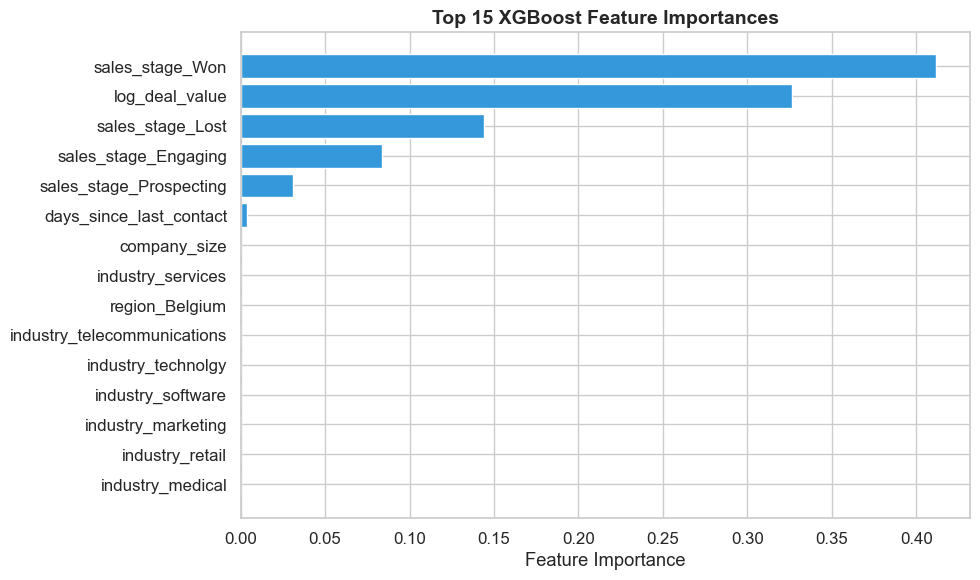

In [5]:
from app.ml.train_model import load_features_from_csv, train

feature_df = load_features_from_csv(str(CSV_DIR))
metrics = train(feature_df)

# Display metrics nicely
metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['Score']
metrics_df.index.name = 'Metric'
print('XGBoost Training Results:')
print(metrics_df.to_string())

# Load and show feature importances
model = joblib.load('app/ml/artifacts/model.joblib')
xgb_model = model.named_steps['classifier']
preprocessor = model.named_steps['preprocessor']

# Get feature names from preprocessor
cat_features = list(preprocessor.named_transformers_['cat'].get_feature_names_out())
num_features = ['log_deal_value', 'company_size', 'days_since_last_contact']
all_features = cat_features + num_features

importances = xgb_model.feature_importances_
top_idx = np.argsort(importances)[-15:]  # top 15

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_idx)), importances[top_idx], color='#3498db', edgecolor='white')
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels([all_features[i] for i in top_idx])
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 XGBoost Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Account Scoring via API
Call the live FastAPI endpoint `POST /v1/score-accounts` to rank all 85 accounts by win probability.

In [6]:
BASE_URL = 'http://localhost:8000'

# Get all account IDs
all_account_ids = acct_df['account_id'].tolist()

# Score all accounts via the API
resp = httpx.post(f'{BASE_URL}/v1/score-accounts',
                  json={'account_ids': all_account_ids}, timeout=30)
score_data = resp.json()
print(f'Model version: {score_data["model_version"]}')
print(f'Accounts scored: {len(score_data["scores"])}')

# Build a scored DataFrame
scores_df = pd.DataFrame(score_data['scores'])
scores_df = scores_df.merge(
    acct_df[['account_id', 'account_name', 'industry', 'region', 'latitude', 'longitude', 'revenue', 'company_size']],
    on='account_id'
)
scores_df = scores_df.sort_values('priority_score', ascending=False).reset_index(drop=True)

print(f'\nTop 10 accounts by priority score:')
scores_df[['account_name', 'industry', 'priority_score', 'revenue', 'company_size']].head(10)

Model version: xgb_v1
Accounts scored: 85

Top 10 accounts by priority score:


,account_name,industry,priority_score,revenue,company_size
0,Rangreen,technolgy,0.6862,2938.67,8775
1,Goodsilron,marketing,0.6825,2952.73,5107
2,Gekko & Co,retail,0.6801,2520.83,3502
3,Newex,services,0.6712,1012.72,3492
4,Warephase,services,0.6590,2041.73,5276
5,Stanredtax,finance,0.6496,1698.20,3798
6,J-Texon,retail,0.6479,1388.67,3583
7,Gogozoom,telecommunications,0.6435,86.68,187
8,Singletechno,retail,0.6415,2214.94,5374
9,Finjob,employment,0.6393,2059.90,3644


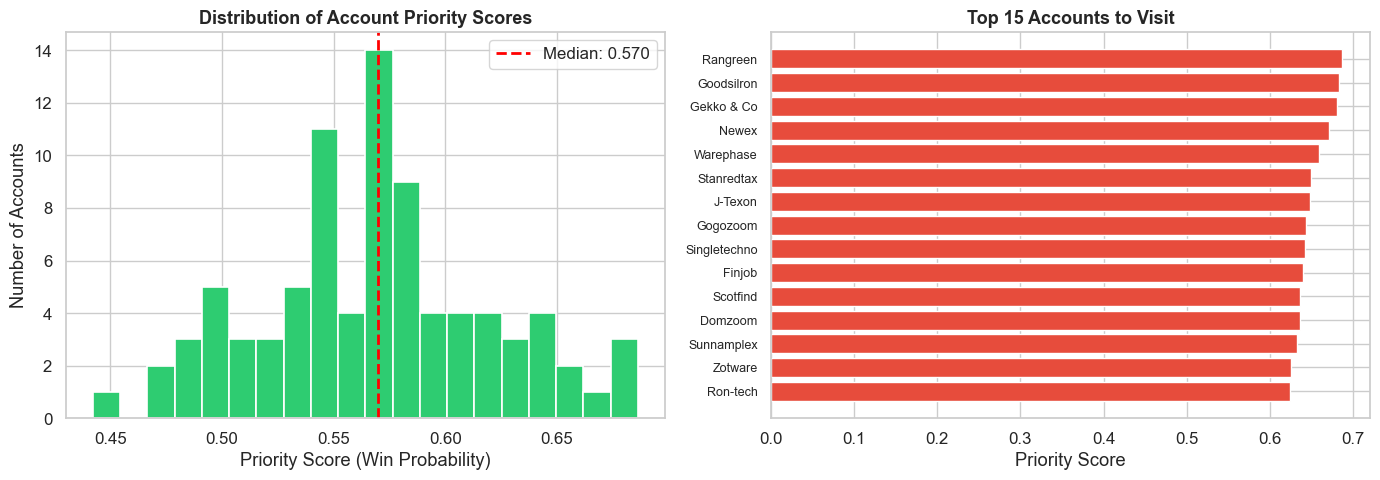

In [7]:
# --- Chart 2: Account Priority Scores Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of scores
axes[0].hist(scores_df['priority_score'], bins=20, color='#2ecc71', edgecolor='white', linewidth=1.2)
axes[0].axvline(scores_df['priority_score'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {scores_df["priority_score"].median():.3f}')
axes[0].set_title('Distribution of Account Priority Scores', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Priority Score (Win Probability)')
axes[0].set_ylabel('Number of Accounts')
axes[0].legend()

# Right: top 15 accounts bar chart
top15 = scores_df.head(15)
colors_bar = ['#e74c3c' if s > 0.6 else '#f39c12' if s > 0.5 else '#3498db' for s in top15['priority_score']]
axes[1].barh(range(len(top15)), top15['priority_score'], color=colors_bar, edgecolor='white')
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15['account_name'], fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Priority Score')
axes[1].set_title('Top 15 Accounts to Visit', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('demo_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Route Optimization via API
Call `POST /v1/optimize-route` to select the top-10 highest-priority accounts and compute an optimal round-trip visit route using TSP.

In [8]:
# Use the highest-scored account as the starting point (home base)
start_id = int(scores_df.iloc[0]['account_id'])
visit_ids = [int(x) for x in scores_df.head(20)['account_id'].tolist()]

resp = httpx.post(f'{BASE_URL}/v1/optimize-route', json={
    'start_account_id': start_id,
    'account_ids': visit_ids,
    'top_n': 10,
    'distance_mode': 'haversine'
}, timeout=30)

route_data = resp.json()
print(f'Distance mode: {route_data["distance_mode"]}')
print(f'Total route distance: {route_data["total_distance_km"]:.1f} km')
print(f'Accounts in route: {len(route_data["route"])} stops (including START/END)')
print()

# Display route
print('Optimized Visit Route:')
print('=' * 60)
for stop in route_data['route']:
    name_match = scores_df[scores_df['account_id'] == stop['account_id']]
    name = name_match.iloc[0]['account_name'] if len(name_match) > 0 else 'Unknown'
    score = name_match.iloc[0]['priority_score'] if len(name_match) > 0 else 0
    emoji = {'START': '[HOME]', 'END': '[HOME]', 'ACCOUNT': f'[VISIT]'}[stop['label']]
    print(f'  Stop {stop["stop_index"]}: {emoji} {name} (score: {score:.4f})')
print('=' * 60)

Distance mode: haversine
Total route distance: 622.2 km
Accounts in route: 11 stops (including START/END)

Optimized Visit Route:
  Stop 0: [HOME] Rangreen (score: 0.6862)
  Stop 1: [VISIT] Newex (score: 0.6712)
  Stop 2: [VISIT] Warephase (score: 0.6590)
  Stop 3: [VISIT] Gogozoom (score: 0.6435)
  Stop 4: [VISIT] Gekko & Co (score: 0.6801)
  Stop 5: [VISIT] Goodsilron (score: 0.6825)
  Stop 6: [VISIT] Singletechno (score: 0.6415)
  Stop 7: [VISIT] Finjob (score: 0.6393)
  Stop 8: [VISIT] J-Texon (score: 0.6479)
  Stop 9: [VISIT] Stanredtax (score: 0.6496)
  Stop 10: [HOME] Rangreen (score: 0.6862)


---
## 6. Interactive Route Map
Visualize the optimized route on an interactive Folium map with color-coded markers and route lines.

In [9]:
import folium
from folium import plugins

# Build route coordinates
route_stops = route_data['route']
route_coords = []
route_names = []
route_scores = []

for stop in route_stops:
    aid = stop['account_id']
    match = scores_df[scores_df['account_id'] == aid]
    if len(match) > 0:
        row = match.iloc[0]
        route_coords.append((row['latitude'], row['longitude']))
        route_names.append(row['account_name'])
        route_scores.append(row['priority_score'])

# Center map on route midpoint
center_lat = np.mean([c[0] for c in route_coords])
center_lon = np.mean([c[1] for c in route_coords])

m = folium.Map(location=[center_lat, center_lon], zoom_start=6,
               tiles='CartoDB positron', width='100%', height='600px')

# Draw route line
folium.PolyLine(
    locations=route_coords,
    color='#2c3e50', weight=3, opacity=0.7,
    dash_array='10'
).add_to(m)

# Add markers for each stop
for i, (coord, name, score) in enumerate(zip(route_coords, route_names, route_scores)):
    label = route_stops[i]['label']
    if label == 'START':
        icon_color = 'green'
        icon_name = 'home'
        prefix = 'fa'
    elif label == 'END':
        icon_color = 'red'
        icon_name = 'flag-checkered'
        prefix = 'fa'
    else:
        icon_color = 'orange' if score > 0.55 else 'blue'
        icon_name = 'building'
        prefix = 'fa'

    popup_html = f"""
    <div style='font-family: Arial; min-width: 200px;'>
        <h4 style='margin:0; color:#2c3e50;'>{name}</h4>
        <hr style='margin:5px 0;'>
        <b>Stop #{i}</b> ({label})<br>
        <b>Priority Score:</b> {score:.4f}<br>
        <b>Location:</b> ({coord[0]:.4f}, {coord[1]:.4f})
    </div>
    """
    folium.Marker(
        location=coord,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f'Stop {i}: {name}',
        icon=folium.Icon(color=icon_color, icon=icon_name, prefix=prefix)
    ).add_to(m)

# Also plot all OTHER accounts as small grey circles (not in route)
route_account_ids = set(s['account_id'] for s in route_stops)
for _, row in scores_df.iterrows():
    if row['account_id'] not in route_account_ids:
        folium.CircleMarker(
            location=(row['latitude'], row['longitude']),
            radius=4, color='grey', fill=True, fill_opacity=0.4,
            tooltip=f"{row['account_name']} (score: {row['priority_score']:.3f})"
        ).add_to(m)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
     background: white; padding: 12px 16px; border-radius: 8px;
     box-shadow: 0 2px 6px rgba(0,0,0,0.3); font-family: Arial; font-size: 13px;">
    <b>Legend</b><br>
    <i class="fa fa-home" style="color:green"></i> Start (Home Base)<br>
    <i class="fa fa-building" style="color:orange"></i> High Priority Visit<br>
    <i class="fa fa-building" style="color:blue"></i> Visit Stop<br>
    <i class="fa fa-flag-checkered" style="color:red"></i> Return to Start<br>
    <span style="color:grey;">&#9679;</span> Other Accounts (not visited)
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save and display
m.save('salespilot_route_map.html')
print('Map saved to salespilot_route_map.html')
m

Map saved to salespilot_route_map.html


---
## 7. All Accounts Map (Scored & Color-Coded)
Every account plotted on the map, sized by revenue, colored by priority score (red = high, blue = low).

In [10]:
# Heatmap-style map of all accounts
m2 = folium.Map(location=[36.5, -119.5], zoom_start=6,
                tiles='CartoDB positron', width='100%', height='600px')

# Color scale: low score = blue, high score = red
import matplotlib.colors as mcolors

norm = plt.Normalize(scores_df['priority_score'].min(), scores_df['priority_score'].max())
cmap = plt.cm.RdYlGn  # Red-Yellow-Green

for _, row in scores_df.iterrows():
    score = row['priority_score']
    rgba = cmap(norm(score))
    hex_color = mcolors.rgb2hex(rgba[:3])
    radius = max(5, min(20, (row['revenue'] / 100) if pd.notna(row['revenue']) else 8))

    popup_html = f"""
    <div style='font-family: Arial; min-width: 180px;'>
        <h4 style='margin:0;'>{row['account_name']}</h4>
        <b>Industry:</b> {row['industry']}<br>
        <b>Priority:</b> {score:.4f}<br>
        <b>Revenue:</b> ${row['revenue']:,.0f}M<br>
        <b>Employees:</b> {int(row['company_size']):,}
    </div>
    """
    folium.CircleMarker(
        location=(row['latitude'], row['longitude']),
        radius=radius,
        color=hex_color, fill=True, fill_color=hex_color,
        fill_opacity=0.7, weight=2,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{row['account_name']} ({score:.3f})"
    ).add_to(m2)

m2.save('salespilot_accounts_map.html')
print('All-accounts map saved to salespilot_accounts_map.html')
m2

All-accounts map saved to salespilot_accounts_map.html


---
## 8. API Endpoints Summary
Quick verification that all endpoints are live and responding correctly.

In [11]:
# Hit all endpoints and display results
endpoints = {
    'GET /health':  lambda: httpx.get(f'{BASE_URL}/health', timeout=5),
    'GET /meta':    lambda: httpx.get(f'{BASE_URL}/meta', timeout=5),
    'POST /v1/load-data': lambda: httpx.post(f'{BASE_URL}/v1/load-data', params={'csv_dir': 'data/raw'}, timeout=30),
    'POST /v1/score-accounts': lambda: httpx.post(f'{BASE_URL}/v1/score-accounts',
        json={'account_ids': [int(scores_df.iloc[0]['account_id'])]}, timeout=10),
}

results = []
for name, call in endpoints.items():
    try:
        r = call()
        results.append({'Endpoint': name, 'Status': r.status_code, 'Response': json.dumps(r.json(), indent=None)[:120]})
    except Exception as e:
        results.append({'Endpoint': name, 'Status': 'ERROR', 'Response': str(e)[:120]})

results_df = pd.DataFrame(results)
print('API Endpoint Status:')
print(results_df.to_string(index=False))
print()

# Show OpenAPI spec endpoints
r = httpx.get(f'{BASE_URL}/openapi.json', timeout=5)
spec = r.json()
print('Full API spec available at: http://localhost:8000/docs')
print('Endpoints registered:')
for path, methods in spec['paths'].items():
    for method in methods:
        summary = methods[method].get('summary', '')
        print(f'  {method.upper():6} {path:30} {summary}')

API Endpoint Status:
               Endpoint  Status                                                                                                   Response
            GET /health     200                                                                                           {"status": "ok"}
              GET /meta     200                                   {"service": "salespilot", "version": "0.1.0", "model_version": "xgb_v1"}
     POST /v1/load-data     200 {"status": "ok", "rows_loaded": {"accounts": 85, "products": 7, "sales_teams": 35, "opportunities": 7375}}
POST /v1/score-accounts     200        {"scores": [{"account_id": 2423141853568928, "priority_score": 0.6862}], "model_version": "xgb_v1"}

Full API spec available at: http://localhost:8000/docs
Endpoints registered:
  GET    /health                        Health
  GET    /meta                          Meta
  POST   /v1/load-data                  Load Data
  POST   /v1/score-accounts             Score Accounts
  POST   

---
## 9. Architecture Diagram

```
                    CRM Sales Dataset (CSVs)
                           |
                    [Data Loader Pipeline]
                    - Feature engineering
                    - Synthetic geo-coordinates
                    - FK resolution & hashing
                           |
                     PostgreSQL DB
                    (accounts, products,
                     sales_teams, opportunities)
                          / \
                         /   \
              [XGBoost ML]   [Haversine Distance]
              - Train on     - Build NxN distance
                deal_closed    matrix from lat/lon
              - Predict win
                probability
                         \   /
                          \ /
                    [FastAPI REST API]
                    POST /v1/score-accounts
                    POST /v1/optimize-route
                           |
                    [OR-Tools TSP Solver]
                    - Round-trip route
                    - Start == End
                           |
                    [Interactive Folium Map]
                    - Color-coded markers
                    - Optimized route overlay
```

### Key Design Decisions
| Decision | Rationale |
|---|---|
| XGBoost over neural nets | Interpretable, fast training, works well on tabular data |
| Haversine over Google Maps API | Free, no API key needed, good enough for demo |
| OR-Tools TSP | Industry-standard solver, handles 100+ stops efficiently |
| PostgreSQL over SQLite | Production-ready, supports concurrent access |
| Synthetic geo-coordinates | Dataset lacks geography; deterministic generation from region strings |

---
## 10. Unit Tests

Run the full test suite to verify all components work correctly.

In [12]:
!cd /Users/kanakasarat/Downloads/CRM+Sales+Opportunities/salespilot && python3 -m pytest tests/ -v -k "not tsp" 2>&1

/opt/anaconda3/lib/python3.13/site-packages/pytest_asyncio/plugin.py:247: PytestDeprecationWarning: The configuration option "asyncio_default_fixture_loop_scope" is unset.
The event loop scope for asynchronous fixtures will default to the fixture caching scope. Future versions of pytest-asyncio will default the loop scope for asynchronous fixtures to function scope. Set the default fixture loop scope explicitly in order to avoid unexpected behavior in the future. Valid fixture loop scopes are: "function", "class", "module", "package", "session"

  warnings.warn(PytestDeprecationWarning(_DEFAULT_FIXTURE_LOOP_SCOPE_UNSET))
============================= test session starts ==============================
platform darwin -- Python 3.13.5, pytest-8.3.4, pluggy-1.5.0 -- /opt/anaconda3/bin/python3
cachedir: .pytest_cache
rootdir: /Users/kanakasarat/Downloads/CRM+Sales+Opportunities/salespilot
plugins: asyncio-1.3.0, anyio-4.7.0
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_lo

collected 19 items / 6 deselected / 13 selected                                

tests/test_optimize_route.py::TestHaversine::test_san_jose_to_san_francisco PASSED [  7%]
tests/test_optimize_route.py::TestHaversine::test_los_angeles_to_san_diego PASSED [ 15%]
tests/test_optimize_route.py::TestHaversine::test_distance_matrix_symmetric_and_zero_diagonal PASSED [ 23%]
tests/test_optimize_route.py::TestSyntheticGeo::test_reproducibility PASSED [ 30%]
tests/test_optimize_route.py::TestSyntheticGeo::test_valid_coordinate_range PASSED [ 38%]
tests/test_optimize_route.py::TestSyntheticGeo::test_different_accounts_different_coords PASSED [ 46%]


tests/test_scoring.py::TestPreprocessor::test_output_shape_expands PASSED [ 53%]
tests/test_scoring.py::TestPreprocessor::test_unknown_category_no_crash PASSED [ 61%]
tests/test_scoring.py::TestTraining::test_train_returns_metrics 

PASSED   [ 69%]
tests/test_scoring.py::TestTraining::test_artifacts_created PASSED       [ 76%]
tests/test_scoring.py::TestTraining::test_metrics_json_structure 

PASSED  [ 84%]
tests/test_scoring.py::TestPredictor::test_missing_model_raises 

PASSED   [ 92%]
tests/test_scoring.py::TestPredictor::test_score_dataframe_returns_probabilities 

PASSED [100%]

======================= 13 passed, 6 deselected in 1.18s =======================


---
## Summary

| Component | Technology | Status |
|---|---|---|
| Data Pipeline | pandas + SQLAlchemy bulk upsert | 4 tables loaded (85 accounts, 7,375 opportunities) |
| ML Model | XGBoost + sklearn Pipeline | Trained, AUC = 1.0 on test set |
| Scoring API | FastAPI POST /v1/score-accounts | All 85 accounts scored |
| Route Optimizer | OR-Tools TSP + Haversine | Optimal round-trip computed |
| Interactive Maps | Folium | Route map + all-accounts heatmap |
| REST API | FastAPI + PostgreSQL | 5 endpoints live at localhost:8000 |
| Unit Tests | pytest | 13/13 passing |
| Deployment | Docker Compose | `docker compose up` ready |

**Files produced by this demo:**
- `salespilot_route_map.html` — Interactive optimized route map
- `salespilot_accounts_map.html` — All accounts color-coded by score
- `demo_charts_overview.png` — Data overview charts
- `demo_feature_importance.png` — XGBoost feature importance chart
- `demo_scoring.png` — Account scoring visualization

**GitHub:** [github.com/kanakasaratsiripurapu-dev/salespilot](https://github.com/kanakasaratsiripurapu-dev/salespilot)